# Gene Expression Analysis under Oxidative Stress

## Introduction
This project analyzes how normal pancreatic cells (hTERT-HPNE) and tumor cells 
(PANC-1) respond to oxidative stress induced by H2O2, through differential gene 
expression analysis using RNA-seq data from study GSE196284 (Liu et al., Antioxidants, 2022).

## Dataset
- **Source:** Gene Expression Omnibus (GEO) — GSE196284
- **Organism:** Homo sapiens
- **Data type:** RNA-seq raw counts
- **Conditions:** Normal cells (HPNE) vs tumor cells (PANC-1), with and without H2O2 treatment

## Data Dictionary
| Sample | Cell type | Condition |
|--------|-----------|-----------|
| GSM5866903 | hTERT-HPNE (normal) | Control |
| GSM5866904 | hTERT-HPNE (normal) | H2O2 (oxidative stress) |
| GSM5866905 | PANC-1 (tumor) | Control |
| GSM5866906 | PANC-1 (tumor) | H2O2 (oxidative stress) |

## Objectives
1. Explore and understand the structure and quality of gene expression data
2. Identify differentially expressed genes between conditions
3. Build a classification model to predict cell type and condition
4. Deploy results as a REST API in the cloud

In [16]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [17]:
# Visualization settings

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data loading

In [18]:
# Dataset loading
df_counts_raw = pd.read_csv(
    '../data/GSE196284_raw_counts_GRCh38.p13_NCBI.tsv.gz',
    sep='\t',
    compression='gzip'
)

print(f"Dataset cargado: {df_counts_raw.shape[0]} genes x {df_counts_raw.shape[1]} columnas")
df_counts_raw.head()

Dataset cargado: 39376 genes x 5 columnas


,GeneID,GSM5866903,GSM5866904,GSM5866905,GSM5866906
0,100287102,4,7,21,14
1,653635,241,305,611,652
2,102466751,6,17,26,39
3,107985730,0,0,0,0
4,100302278,0,0,0,0


We load the raw count matrix from GEO dataset GSE196284, which contains 
RNA-seq expression data for normal pancreatic cells (HPNE) and tumor cells 
(PANC-1) under oxidative stress conditions.

## 2. Column renaming

In [19]:
# Rename columns with meaningful names
df_counts_raw.rename(columns={
    'GSM5866903': 'HPNE_Control',
    'GSM5866904': 'HPNE_H2O2',
    'GSM5866905': 'PANC1_Control',
    'GSM5866906': 'PANC1_H2O2'
}, inplace=True)

df_counts_raw.head()

,GeneID,HPNE_Control,HPNE_H2O2,PANC1_Control,PANC1_H2O2
0,100287102,4,7,21,14
1,653635,241,305,611,652
2,102466751,6,17,26,39
3,107985730,0,0,0,0
4,100302278,0,0,0,0


We rename the sample columns from GEO accession codes to meaningful names 
that reflect the cell type and experimental condition.

## 3. Gene annotation

In [20]:
# Load gene annotation
df_annot = pd.read_csv(
    '../data/Human.GRCh38.p13.annot.tsv.gz',
    sep='\t',
    compression='gzip'
)

df_annot.head()

C:\Users\Federica\AppData\Local\Temp\ipykernel_7572\3128641179.py:2: DtypeWarning: Columns (0: ChrStart, 1: ChrStop) have mixed types. Specify dtype option on import or set low_memory=False.
  df_annot = pd.read_csv(


,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN


In [21]:
# Merge counts with gene annotation
df_counts_raw = df_counts_raw.merge(
    df_annot[['GeneID', 'Symbol']],
    on='GeneID',
    how='left'
)

# Set gene symbol as index
df_counts_raw = df_counts_raw.set_index('Symbol').drop(columns=['GeneID'])

df_counts_raw.head()

,HPNE_Control,HPNE_H2O2,PANC1_Control,PANC1_H2O2
Symbol,,,,
DDX11L1,4,7,21,14
WASH7P,241,305,611,652
MIR6859-1,6,17,26,39
MIR1302-2HG,0,0,0,0
MIR1302-2,0,0,0,0


We merge the count matrix with the NCBI gene annotation table to replace 
numeric Gene IDs with standard gene symbols (e.g. TP53, BRCA1).

## 4. Initial Exploration

We explore the basic structure of the dataset to understand its dimensions, 
data types, and statistical properties.

In [22]:
df_counts_raw.info()

<class 'pandas.DataFrame'>
Index: 39376 entries, DDX11L1 to TRNP
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   HPNE_Control   39376 non-null  int64
 1   HPNE_H2O2      39376 non-null  int64
 2   PANC1_Control  39376 non-null  int64
 3   PANC1_H2O2     39376 non-null  int64
dtypes: int64(4)
memory usage: 1.5+ MB


In [23]:
df_counts_raw.describe()

,HPNE_Control,HPNE_H2O2,PANC1_Control,PANC1_H2O2
count,3.937600e+04,3.937600e+04,39376.000000,39376.000000
mean,8.553432e+02,8.247941e+02,1334.672135,1146.625533
std,1.358934e+04,1.721197e+04,8416.512797,6903.697262
min,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,4.000000e+00,6.000000e+00,7.000000,6.000000
75%,2.930000e+02,2.740000e+02,461.250000,415.500000
max,1.701589e+06,2.331029e+06,751851.000000,611011.000000


The median count across samples is very low (4-7 reads), while the maximum 
reaches millions. This wide range is typical of RNA-seq data and confirms 
the need for normalization in later steps.

## 5. Data Quality Check

We check for duplicates, null values, and genes with zero expression across 
all samples, which would not contribute to the differential expression analysis.

In [24]:
# Check duplicates, nulls and zero-count genes
print("=== Data Quality Check ===\n")

# Duplicates
duplicates = df_counts_raw.index.duplicated().sum()
print(f"Duplicate gene symbols: {duplicates}")

# Null gene symbols
null_symbols = df_counts_raw.index.isna().sum()
print(f"Null gene symbols: {null_symbols}")

# Null values in counts
null_counts = df_counts_raw.isnull().sum().sum()
print(f"Null values in counts: {null_counts}")

# Zero-count genes
total_genes = len(df_counts_raw)
zero_genes = (df_counts_raw.sum(axis=1) == 0).sum()
print(f"\nTotal genes: {total_genes}")
print(f"Genes with zero counts in all samples: {zero_genes} ({zero_genes/total_genes*100:.1f}%)")
print(f"Genes with some expression: {total_genes - zero_genes}")

=== Data Quality Check ===

Duplicate gene symbols: 2
Null gene symbols: 0
Null values in counts: 0

Total genes: 39376
Genes with zero counts in all samples: 8438 (21.4%)
Genes with some expression: 30938


In [25]:
# Fix data quality issues

# 1. Remove duplicate gene symbols
df_counts_raw = df_counts_raw[~df_counts_raw.index.duplicated(keep='first')]
print(f"After removing duplicates: {len(df_counts_raw)} genes")

# 2. Remove genes with zero counts in all samples
df_counts_filtered = df_counts_raw[df_counts_raw.sum(axis=1) > 0]
print(f"After removing zero-count genes: {len(df_counts_filtered)} genes")
print(f"Genes removed: {len(df_counts_raw) - len(df_counts_filtered)}")

After removing duplicates: 39374 genes
After removing zero-count genes: 30936 genes
Genes removed: 8438


We found 2 duplicate gene symbols and 8,438 genes (21.4%) with zero counts 
across all samples. After filtering, 30,936 genes remain for analysis.

## 6. Outlier Detection
We identify genes with extremely high counts that could disproportionately 
influence the analysis.

In [26]:
# Identify outliers using IQR method per sample
print("=== Outlier Detection ===\n")

for col in df_counts_filtered.columns:
    Q1 = df_counts_filtered[col].quantile(0.25)
    Q3 = df_counts_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_counts_filtered[df_counts_filtered[col] > upper_bound][col]
    print(f"{col}: {len(outliers)} outliers (upper bound: {upper_bound:.0f} counts)")

=== Outlier Detection ===

HPNE_Control: 4153 outliers (upper bound: 1411 counts)
HPNE_H2O2: 4123 outliers (upper bound: 1292 counts)
PANC1_Control: 4464 outliers (upper bound: 2531 counts)
PANC1_H2O2: 4480 outliers (upper bound: 2252 counts)


RNA-seq data typically contains many genes with extremely high counts, which 
represent highly expressed genes (e.g. housekeeping genes). Unlike tabular data, 
these are not removed — instead, they are handled through log transformation 
and normalization in the preprocessing step.

## 7. Count Distribution

We visualize the distribution of raw counts per sample using a log transformation 
(log1p) to handle the wide range of values. This helps us understand the overall 
expression profile of each sample and detect potential quality issues.

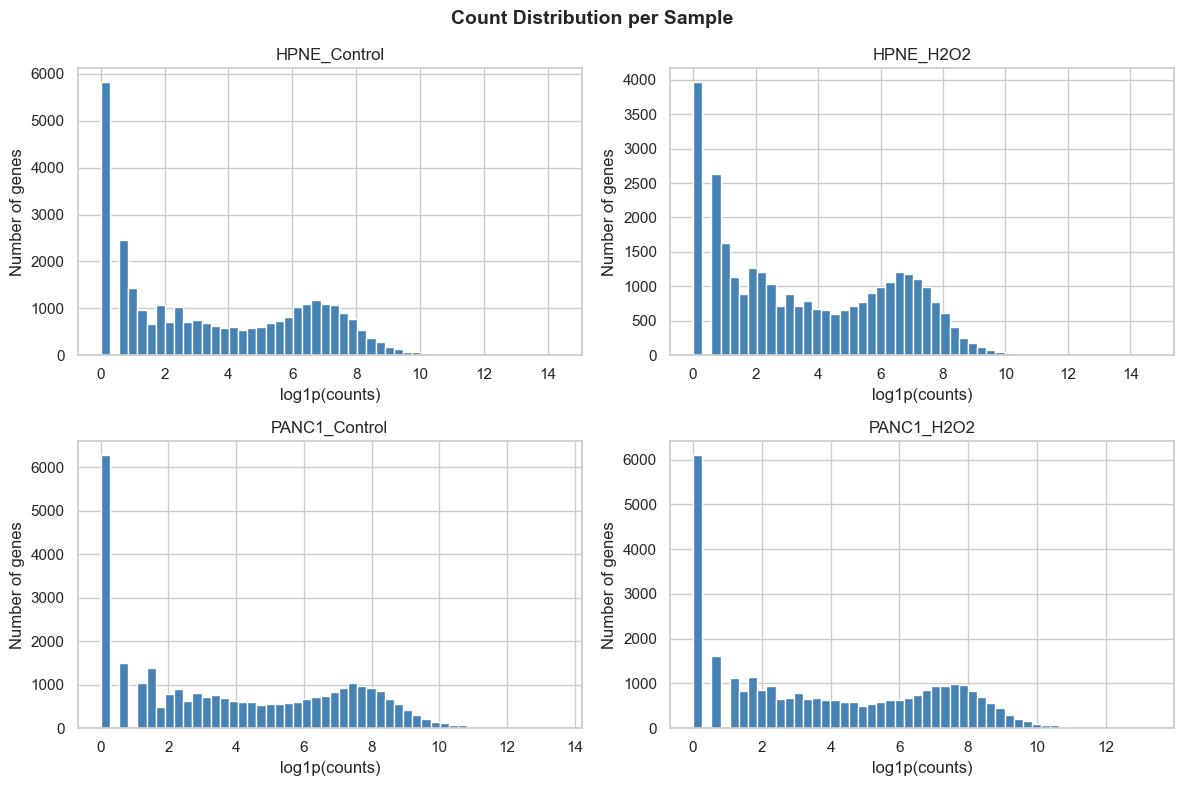

In [27]:
# Distribution of counts per sample
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(df_counts_filtered.columns):
    axes[i].hist(np.log1p(df_counts_filtered[col]), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('log1p(counts)')
    axes[i].set_ylabel('Number of genes')

plt.suptitle('Count Distribution per Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The count distributions show a bimodal pattern across all samples, typical of 
RNA-seq data. Notably, HPNE_H2O2 shows a broader distribution compared to its 
control, suggesting that oxidative stress activates a larger number of genes in 
normal pancreatic cells. PANC-1 cells show more similar distributions between 
conditions, which may indicate that tumor cells are less transcriptionally 
responsive to H2O2 treatment.

## 8. Expression Level Comparison
We compare the overall expression levels across all four samples using boxplots 
to detect potential differences in sequencing depth or sample quality.

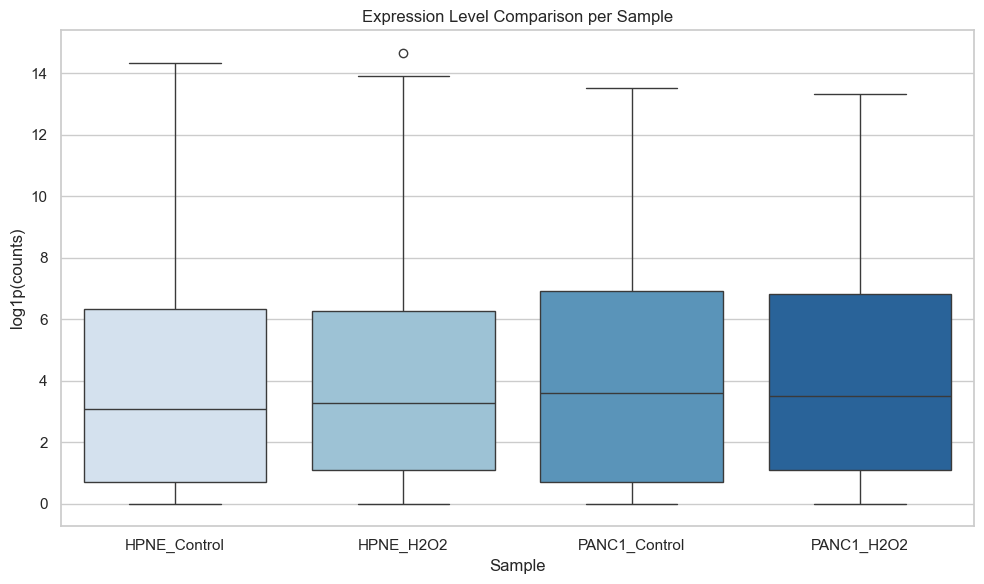

In [28]:
# Boxplot of log-transformed counts per sample
plt.figure(figsize=(10, 6))
sns.boxplot(data=np.log1p(df_counts_filtered), palette='Blues')
plt.title('Expression Level Comparison per Sample')
plt.xlabel('Sample')
plt.ylabel('log1p(counts)')
plt.tight_layout()
plt.show()

The boxplots show similar median expression levels across all four samples, 
suggesting comparable sequencing depth. PANC-1 cells display greater expression 
variability than HPNE cells, which is consistent with the transcriptional 
heterogeneity typically observed in tumor cells. The overall similarity between 
conditions confirms the need for normalization before differential expression analysis.

## 9. Sample Correlation Heatmap
We compute the Pearson correlation between samples to assess their similarity 
and validate the experimental design.

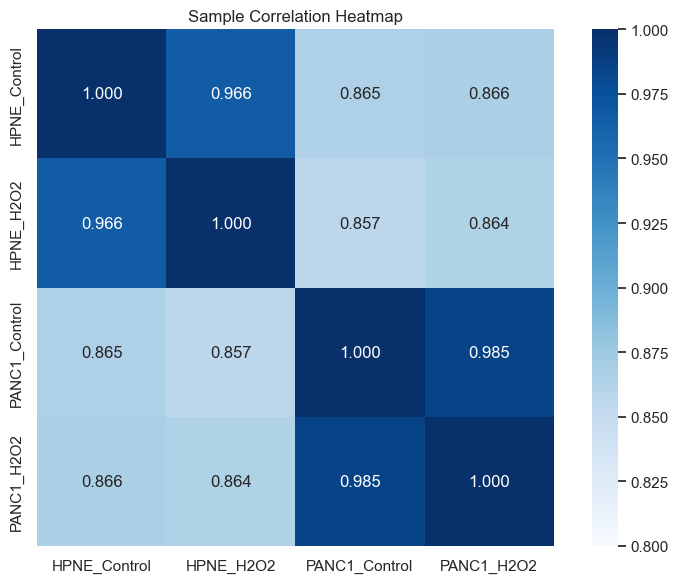

In [29]:
# Correlation heatmap between samples
plt.figure(figsize=(8, 6))
correlation = np.log1p(df_counts_filtered).corr()
sns.heatmap(correlation, annot=True, fmt='.3f', cmap='Blues', 
            vmin=0.8, vmax=1.0, square=True)
plt.title('Sample Correlation Heatmap')
plt.tight_layout()
plt.show()

The correlation heatmap reveals two clear clusters: HPNE samples correlate 
strongly with each other (0.966), and PANC-1 samples show near-identical 
profiles (0.985). Cross-type correlations are lower (0.857-0.866), indicating 
that cell type drives expression differences more than oxidative stress treatment. 
This suggests that tumor cells maintain a stable transcriptional program 
even under H2O2 stress.

## 10. EDA Conclusions

Based on the exploratory analysis, we can draw the following conclusions:

1. **Data quality is good** — no null values, only 2 duplicate gene symbols removed
2. **21.4% of genes show no expression** — 8,438 genes were filtered out, leaving 30,936 for analysis
3. **Outliers are expected** — highly expressed genes are biologically valid and will be handled through normalization
4. **Cell type drives expression differences** — HPNE and PANC-1 samples cluster separately (correlation 0.857-0.866 between types vs 0.966-0.985 within types)
5. **Normalization is required** — count distributions differ between samples, making direct comparison unreliable

**Next steps:** In the preprocessing notebook, we will normalize the data and prepare it for differential expression analysis.

## 11. Export Processed Data
We export the filtered dataset for use in the preprocessing notebook.

In [30]:
# Export filtered dataset
df_counts_filtered.to_csv('../data/counts_filtered.csv')
print(f"Exported: {df_counts_filtered.shape[0]} genes x {df_counts_filtered.shape[1]} samples")

Exported: 30936 genes x 4 samples
